In [1]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
   for gpu in gpus:
       tf.config.experimental.set_memory_growth(gpu, True)

print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# import system libs
import os
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.utils import class_weight
import numpy as np

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

In [3]:
MildDemented_dir = '/Users/Ahmad/UNI-work/year3/FYP/Project/alzheimers/datasets/AugmentedAlzheimerDataset/MildDemented'
ModerateDemented_dir = '/Users/Ahmad/UNI-work/year3/FYP/Project/alzheimers/datasets/AugmentedAlzheimerDataset/ModerateDemented'
NonDemented_dir = '/Users/Ahmad/UNI-work/year3/FYP/Project/alzheimers/datasets/AugmentedAlzheimerDataset/NonDemented'
VeryMildDemented_dir = '/Users/Ahmad/UNI-work/year3/FYP/Project/alzheimers/datasets/AugmentedAlzheimerDataset/VeryMildDemented'

filepaths = []
labels = []
dict_list = [MildDemented_dir, ModerateDemented_dir, NonDemented_dir, VeryMildDemented_dir]
class_labels = ['Mild Demented', 'Moderate Demented', 'Non Demented', 'Very MildDemented']

for i, j in enumerate(dict_list):
    flist = os.listdir(j)
    for f in flist:
        fpath = os.path.join(j, f)
        filepaths.append(fpath)
        labels.append(class_labels[i])

Fseries = pd.Series(filepaths, name="filepaths")
Lseries = pd.Series(labels, name="labels")
Alzheimer_data = pd.concat([Fseries, Lseries], axis=1)
Alzheimer_df = pd.DataFrame(Alzheimer_data)
print(Alzheimer_df.head())
print(Alzheimer_df["labels"].value_counts())

                                           filepaths         labels
0  /Users/Ahmad/UNI-work/year3/FYP/Project/alzhei...  Mild Demented
1  /Users/Ahmad/UNI-work/year3/FYP/Project/alzhei...  Mild Demented
2  /Users/Ahmad/UNI-work/year3/FYP/Project/alzhei...  Mild Demented
3  /Users/Ahmad/UNI-work/year3/FYP/Project/alzhei...  Mild Demented
4  /Users/Ahmad/UNI-work/year3/FYP/Project/alzhei...  Mild Demented
labels
Non Demented         9600
Mild Demented        8960
Very MildDemented    8960
Moderate Demented    6464
Name: count, dtype: int64


In [4]:
from sklearn.model_selection import train_test_split

train_images, test_images = train_test_split(Alzheimer_df, test_size=0.3, random_state=42)
train_set, val_set = train_test_split(Alzheimer_df, test_size=0.2, random_state=42)

In [5]:
# ── 1. FIXED DATA GENERATORS ─────────────────────────────────────────────
# Change preprocessing to simple 1./255 scaling for a scratch model
image_gen = ImageDataGenerator(rescale=1./255)

# Ensure target_size matches your input_shape (224, 224)
train = image_gen.flow_from_dataframe(
    dataframe=train_set, x_col="filepaths", y_col="labels",
    target_size=(224, 224), color_mode='rgb', class_mode="categorical",
    batch_size=32, shuffle=True # Shuffle during training!
)
test = image_gen.flow_from_dataframe(dataframe= test_images,x_col="filepaths", y_col="labels",
                                     target_size=(244,244),
                                     color_mode='rgb',
                                     class_mode="categorical",
                                     batch_size=32,
                                     shuffle= False
                                    )
val = image_gen.flow_from_dataframe(dataframe= val_set,x_col="filepaths", y_col="labels",
                                    target_size=(244,244),
                                    color_mode= 'rgb',
                                    class_mode="categorical",
                                    batch_size=32,
                                    shuffle=False
                                   )

Found 27187 validated image filenames belonging to 4 classes.
Found 10196 validated image filenames belonging to 4 classes.
Found 6797 validated image filenames belonging to 4 classes.


In [6]:
# ── 2. COMPUTE CLASS WEIGHTS ─────────────────────────────────────────────

y_train_indices = train.classes
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_indices),
    y=y_train_indices
)
cw_dict = dict(enumerate(weights))

In [ ]:
# ── 3. OPTIMIZED ARCHITECTURE ────────────────────────────────────────────
model = keras.models.Sequential([
    # Input Layer
    layers.Input(shape=(224, 224, 3)),
    
    # Block 1: Focus on fine MRI textures
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    # Block 2
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    # Block 3: Deeper features
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 4: Global context
    layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(), # Reduces parameters to prevent overfitting

    # Dense Head
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])

2026-04-02 11:34:23.166149: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-04-02 11:34:23.166181: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-02 11:34:23.166188: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-02 11:34:23.166230: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-02 11:34:23.166261: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [8]:
# ── 4. COMPILATION & CALLBACKS ───────────────────────────────────────────
model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # Adam is better for 90%+
    metrics=['accuracy']
)

# Add EarlyStopping to catch the best version of the model
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3)
]

In [9]:
# ── 5. TRAINING ──────────────────────────────────────────────────────────
history = model.fit(
    train,
    validation_data=val,
    epochs=50,
    class_weight=cw_dict, # Applied the "Recall Protection" here
    callbacks=callbacks
)

Epoch 1/50


2026-04-02 11:34:24.085320: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-04-02 11:34:24.153361: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


850/850 [==============================] - 1045s 1s/step - loss: 4.0318 - accuracy: 0.4681 - val_loss: 2.6273 - val_accuracy: 0.4852 - lr: 1.0000e-04
Epoch 2/50
850/850 [==============================] - 1129s 1s/step - loss: 2.1641 - accuracy: 0.5486 - val_loss: 2.1177 - val_accuracy: 0.4118 - lr: 1.0000e-04
Epoch 3/50
850/850 [==============================] - 1091s 1s/step - loss: 1.6073 - accuracy: 0.5758 - val_loss: 1.3308 - val_accuracy: 0.6092 - lr: 1.0000e-04
Epoch 4/50
850/850 [==============================] - 1107s 1s/step - loss: 1.2121 - accuracy: 0.6210 - val_loss: 1.1464 - val_accuracy: 0.5959 - lr: 1.0000e-04
Epoch 5/50
850/850 [==============================] - 1156s 1s/step - loss: 0.8887 - accuracy: 0.6912 - val_loss: 2.9712 - val_accuracy: 0.3878 - lr: 1.0000e-04
Epoch 6/50
850/850 [==============================] - 1145s 1s/step - loss: 0.5881 - accuracy: 0.7857 - val_loss: 0.8943 - val_accuracy: 0.6557 - lr: 1.0000e-04
Epoch 7/50
850/850 [=========================

In [10]:
# ── 10. EVALUATE THE MODEL ────────────────────────────────────────────────
print("\nEvaluating on Test Set...")
evaluation = model.evaluate(test)

print(f"\nTest Loss: {evaluation[0]:.4f}")
print(f"Test Accuracy: {evaluation[1]:.2%}")


Evaluating on Test Set...
319/319 [==============================] - 65s 203ms/step - loss: 0.1485 - accuracy: 0.9555

Test Loss: 0.1485
Test Accuracy: 95.55%


In [11]:
model.save(filepath="/Users/Ahmad/UNI-work/year3/FYP/Project/alzheimers/models/trained/best_alzheimers2.keras")

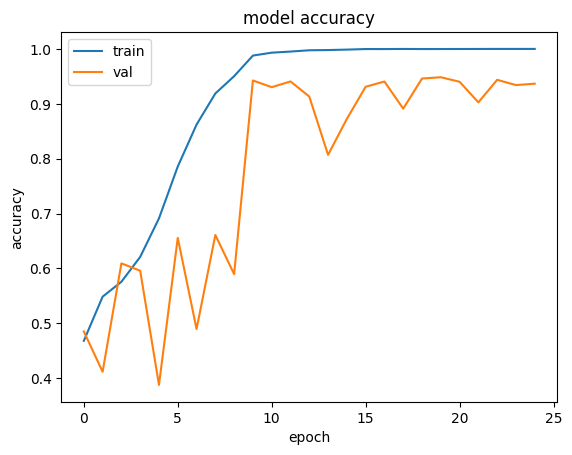

In [12]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

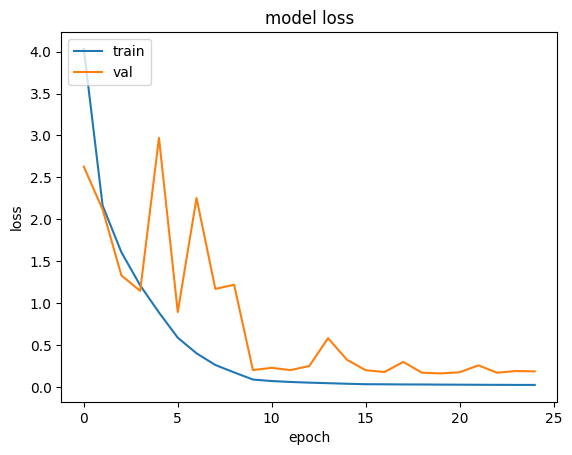

In [13]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [16]:
from sklearn.metrics import confusion_matrix, accuracy_score
pred = model.predict(test)
pred = np.argmax(pred, axis=1) #pick class with highest  probability

labels = (train.class_indices)
labels = dict((v,k) for k,v in labels.items())
pred2 = [labels[k] for k in pred]

y_test = test_images.labels # set y_test to the expected output
print(classification_report(y_test, pred2))
print("Accuracy of the Model:","{:.1f}%".format(accuracy_score(y_test, pred2)*100))

319/319 [==============================] - 65s 204ms/step
                   precision    recall  f1-score   support

    Mild Demented       0.99      0.95      0.97      2693
Moderate Demented       1.00      1.00      1.00      1977
     Non Demented       0.92      0.96      0.94      2811
Very MildDemented       0.94      0.92      0.93      2715

         accuracy                           0.96     10196
        macro avg       0.96      0.96      0.96     10196
     weighted avg       0.96      0.96      0.96     10196

Accuracy of the Model: 95.5%


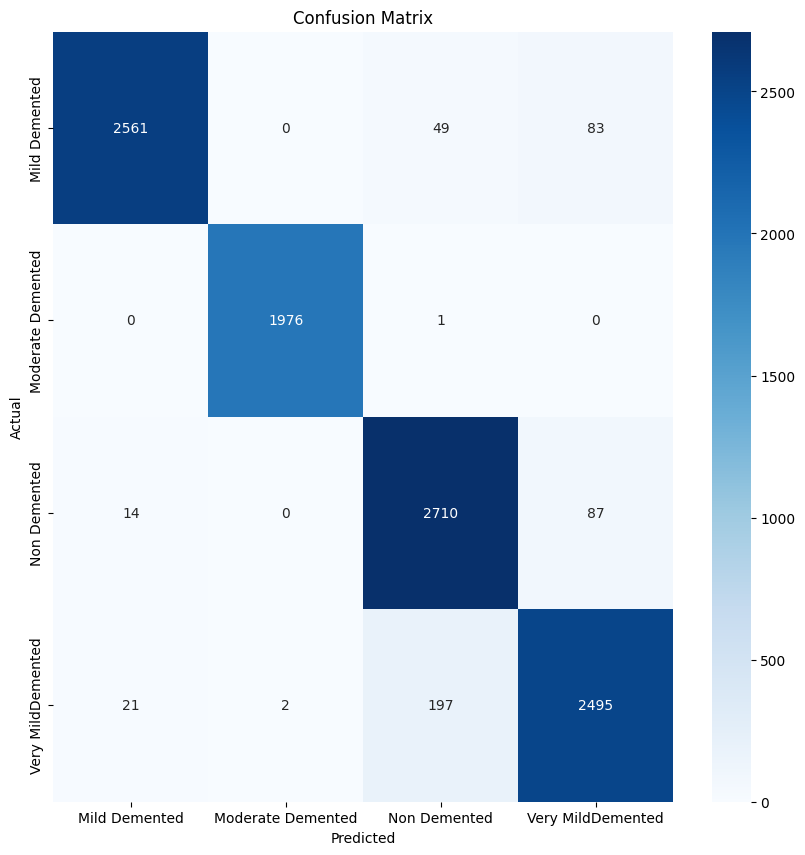

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Define the class labels
class_labels = ['Mild Demented', 'Moderate Demented', 'Non Demented', 'Very MildDemented']

# Calculate the confusion matrix
cm = confusion_matrix(y_test, pred2)

# Create a figure and plot the confusion matrix as a heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=True, fmt='g', vmin=0, cmap='Blues')

# Set tick labels and axis labels
plt.xticks(ticks=[0.5, 1.5, 2.5, 3.5], labels=class_labels)
plt.yticks(ticks=[0.5, 1.5, 2.5, 3.5], labels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Set the title
plt.title("Confusion Matrix")

# Show the plot
plt.show()

In [20]:
from sklearn.metrics import roc_auc_score

y_test = test_images.labels 

y_probs = model.predict(test)
auc_score = roc_auc_score(y_test, y_probs, multi_class='ovr', average='macro')

print(f"Multiclass ROC AUC Score (One-vs-Rest): {auc_score:.4f}")

319/319 [==============================] - 65s 203ms/step
Multiclass ROC AUC Score (One-vs-Rest): 0.9962
